<a href="https://colab.research.google.com/github/lydialuggu2005-yes/Intro-to-data-analysis/blob/main/Mini_Project_Lydia_Oyelere.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exeter Eats Mini Project

## Background

**Exeter Eats** is a growing food delivery company operating across Exeter, United Kingdom. The company partners with local restaurants and delivers meals to customers in different areas of the city.

As the business expands, management wants to better understand customer behaviour, sales performance, and customer satisfaction. In particular, they would like to know:

* Which areas generate the most revenue?
* Whether discounts encourage customers to spend more.
* How delivery performance affects customer satisfaction.
* Which customer groups contribute most to the business.

You have been hired as a **Junior Data Analyst** and have been provided with a dataset containing recent customer orders. Your task is to analyse the data and provide evidence-based recommendations to help Exeter Eats improve its operations and customer experience.

---

# Dataset Variables

| Variable            | Description                                                                                                           | Type                     |
| ------------------- | --------------------------------------------------------------------------------------------------------------------- | ------------------------ |
| **Order_ID**        | Unique identifier for each order.                                                                                     | Categorical (Identifier) |
| **Customer_Age**    | Age of the customer who placed the order.                                                                             | Numerical                |
| **Customer_Gender** | Gender of the customer.                                                                                               | Categorical              |
| **Area**            | Area of Exeter where the order was delivered (e.g., Pennsylvania, Heavitree, Pinhoe, St Thomas, Alphington, Topsham). | Categorical              |
| **Cuisine_Type**    | Type of food ordered.                                                                                                 | Categorical              |
| **Order_Value_GBP** | Total value of the order in British Pounds (£).                                                                       | Numerical                |
| **Discount**    | Yes or No if Discount applied to the order.                      | Categorical                |
| **Customer_Rating** | Customer satisfaction rating for the order on a scale from 1 (very dissatisfied) to 5 (very satisfied).               | Numerical                |
| **Order_Time**      | Time of day when the order was placed (Lunch or Dinner).                                                              | Categorical              |
| **Delivery_Status** | Whether the order was delivered on time or delayed.                                                                   | Categorical              |

---


Remember: **Management is interested in business insights, not just code.** Your goal is to turn data into actionable recommendations for Exeter Eats.


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [4]:
# 1. Load dataset

In [5]:
from google.colab import files
uploaded = files.upload()
file_name = next(iter(uploaded))
df = pd.read_csv(file_name)
df.head()

Saving exeter_eats_mini_project.csv to exeter_eats_mini_project.csv


,Order_ID,Customer_Age,Customer_Gender,Area,Cuisine_Type,Order_Value_GBP,Customer_Rating,Order_Time,Delivery_Status,Discount_Applied
0,ORD0089,35,Male,Pennsylvania,Pizza,26.90,4.0,Lunch,On Time,No
1,ORD0407,56,Male,Topsham,Indian,30.07,4.0,Dinner,On Time,Yes
2,ORD0390,31,Female,Topsham,Burgers,17.10,5.0,Lunch,On Time,No
3,ORD0384,39,Male,Alphington,Chinese,33.86,4.0,Dinner,Delayed,Yes
4,ORD0307,29,Male,Pennsylvania,Indian,34.51,3.0,Lunch,Delayed,Yes


In [5]:
df.shape

(500, 10)

In [ ]:
# 2. Check missing values

In [6]:
df["Customer_Rating"].isna().sum()

np.int64(10)

In [ ]:
# 3. Remove rows with missing Customer_Rating

In [ ]:
df = df.dropna()

In [ ]:
# 4. Checking duplicates

In [7]:
df.duplicated().sum()

np.int64(1)

In [ ]:
# 5. Remove duplicated rows

In [8]:
df = df.drop_duplicates()

In [28]:
 # 6. Write a code get general information on the dataset using the function info()

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          500 non-null    object 
 1   Customer_Age      500 non-null    int64  
 2   Customer_Gender   500 non-null    object 
 3   Area              500 non-null    object 
 4   Cuisine_Type      500 non-null    object 
 5   Order_Value_GBP   500 non-null    float64
 6   Customer_Rating   490 non-null    float64
 7   Order_Time        500 non-null    object 
 8   Delivery_Status   500 non-null    object 
 9   Discount_Applied  500 non-null    object 
dtypes: float64(2), int64(1), object(7)
memory usage: 39.2+ KB


In [36]:
# Now use the function describe to the dataset

In [38]:
df.describe()

,Customer_Age,Order_Value_GBP,Customer_Rating
count,500.000000,500.000000,490.000000
mean,37.664000,27.538160,4.069388
std,11.553097,6.980672,0.758915
min,18.000000,9.350000,2.000000
25%,30.000000,22.727500,4.000000
50%,36.000000,27.405000,4.000000
75%,46.000000,32.042500,5.000000
max,70.000000,51.420000,5.000000


In [39]:
df.columns

Index(['Order_ID', 'Customer_Age', 'Customer_Gender', 'Area', 'Cuisine_Type',
       'Order_Value_GBP', 'Customer_Rating', 'Order_Time', 'Delivery_Status',
       'Discount_Applied'],
      dtype='object')

**Question 1: Does delivery performance affect customer satisfaction?**

In [40]:
# 1. Delivery Status Distribution
df["Delivery_Status"].value_counts()

,count
Delivery_Status,
On Time,407
Delayed,93


In [41]:
df["Delivery_Status"].value_counts(normalize=True)

,proportion
Delivery_Status,
On Time,0.814
Delayed,0.186


<BarContainer object of 2 artists>

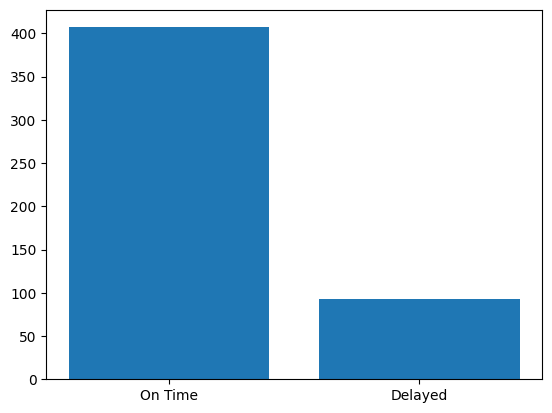

In [42]:
delivery_count = df["Delivery_Status"].value_counts()
plt.bar(
    delivery_count.index,
    delivery_count.values
)

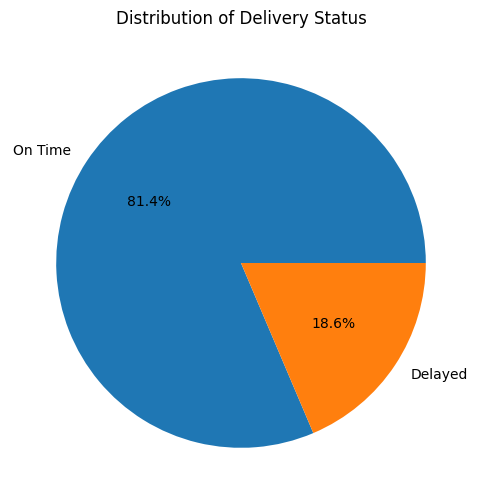

In [43]:
delivery_counts = df["Delivery_Status"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    delivery_counts,
    labels=delivery_counts.index,
    autopct="%1.1f%%"
)

plt.title("Distribution of Delivery Status")
plt.show()

In [ ]:
# Most orders were delivered on time, accounting for approximately 81.2% of all deliveries,
# while delayed deliveries represented 18.8%.

# This suggests that the company generally performs well in meeting delivery expectations.

In [44]:
# 2. Customer Rating Distribution
df["Customer_Rating"].value_counts()

,count
Customer_Rating,
4.0,242
5.0,147
3.0,89
2.0,12


In [46]:
# 2. Customer Rating Distribution in percentage
df["Customer_Rating"].value_counts(normalize=True)*100

,proportion
Customer_Rating,
4.0,49.387755
5.0,30.000000
3.0,18.163265
2.0,2.448980


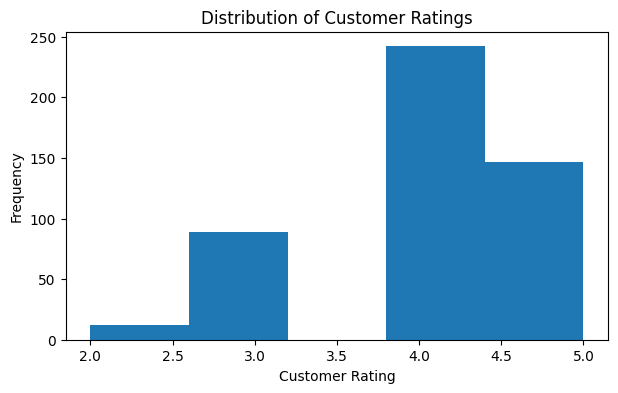

In [45]:
plt.figure(figsize=(7,4))

plt.hist(df["Customer_Rating"], bins=5)

plt.title("Distribution of Customer Ratings")
plt.xlabel("Customer Rating")
plt.ylabel("Frequency")
plt.show()

<BarContainer object of 4 artists>

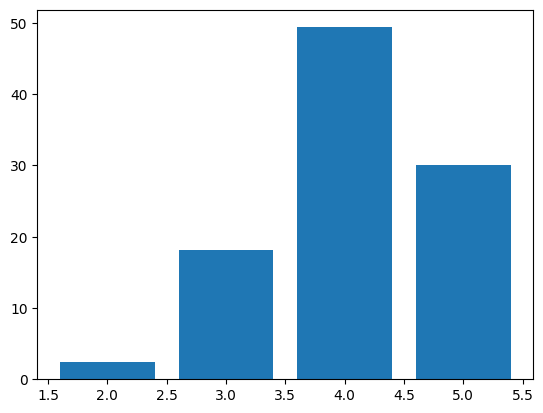

In [48]:
 rating_count = df["Customer_Rating"].value_counts(normalize=True)*100
plt.bar(
    rating_count.index,
    rating_count.values
)

In [ ]:
# only 2.5% of the customers rated the company below 3

# This means the company is well rated

In [49]:
# 3. Compare average rating by delivery status
df.groupby("Delivery_Status")["Customer_Rating"].mean()

,Customer_Rating
Delivery_Status,
Delayed,3.054348
On Time,4.304020


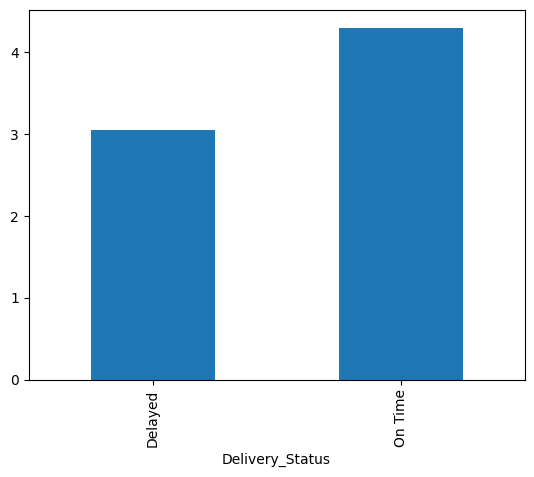

In [50]:
df.groupby("Delivery_Status")["Customer_Rating"].mean().plot(kind="bar")
plt.show()

In [52]:
summary = (
    df
    .groupby("Delivery_Status")["Customer_Rating"]
    .agg(["count","mean","median","std","min","max"])
)

print(summary)

                 count      mean  median       std  min  max
Delivery_Status                                             
Delayed             92  3.054348     3.0  0.581097  2.0  5.0
On Time            398  4.304020     4.0  0.581437  3.0  5.0


**Question 2: Do customers who receive discounts place larger orders than customers who do not receive discounts?**

**Hints:**

* Explore each of the 2 variables
* Calculate the average Order_Value_GBP for each group of Discount_Applied.
* Create a summary table showing the number of orders and average order value for each category.
* Use a bar chart to compare the average order values.

**Expected Deliverables**

* Summary Table
* Bar Chart Comparing Average Order Values
* A short business interpretation (2–3 sentences) explaining whether discounts appear to encourage higher spending.

In [53]:
# 1.Explore each of the 2 variables

In [54]:
df['Discount_Applied'].value_counts()

,count
Discount_Applied,
No,272
Yes,228


In [55]:
df['Discount_Applied'].value_counts(normalize=True)*100

,proportion
Discount_Applied,
No,54.4
Yes,45.6


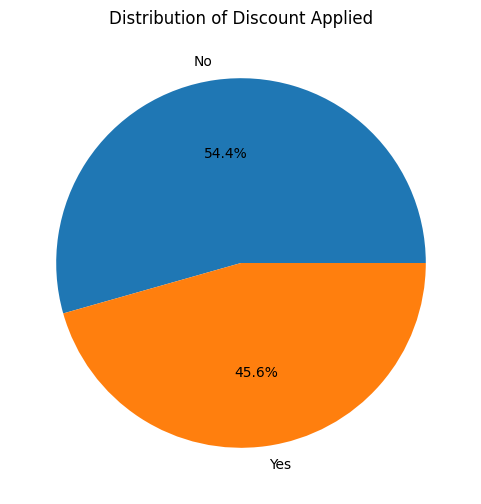

In [56]:
discount_counts = df["Discount_Applied"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    discount_counts,
    labels=discount_counts.index,
    autopct="%1.1f%%"
)

plt.title("Distribution of Discount Applied")
plt.show()

In [57]:
# About 54% of the customers did not receive any discount.

In [58]:
# df['Order_Value_GBP'].value_counts()

In [59]:
df['Order_Value_GBP'].describe()

,Order_Value_GBP
count,500.000000
mean,27.538160
std,6.980672
min,9.350000
25%,22.727500
50%,27.405000
75%,32.042500
max,51.420000


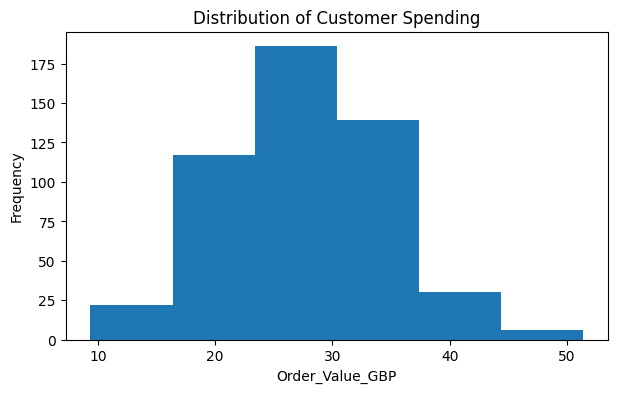

In [60]:
plt.figure(figsize=(7,4))

plt.hist(df["Order_Value_GBP"], bins=6)

plt.title("Distribution of Customer Spending")
plt.xlabel("Order_Value_GBP")
plt.ylabel("Frequency")
plt.show()

In [12]:
df.groupby("Discount_Applied")["Order_Value_GBP"].mean()

,Order_Value_GBP
Discount_Applied,
No,24.662096
Yes,30.969254


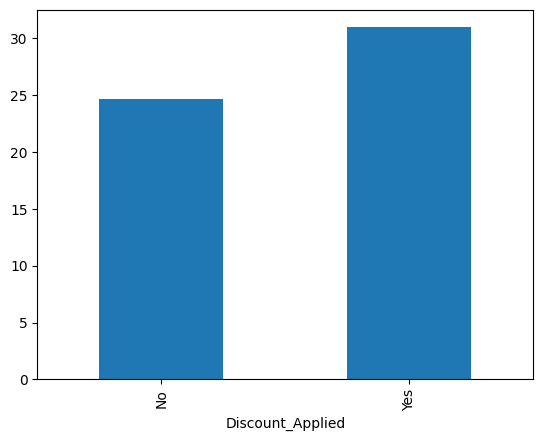

In [13]:
df.groupby("Discount_Applied")["Order_Value_GBP"].mean().plot(kind="bar")
plt.show()

In [14]:
# The average value order is £31 for those who received a discount and £25 for those who did not.

# Customers who receive discounts tend to spend more.

In [16]:
summary = (
    df
    .groupby("Discount_Applied")["Order_Value_GBP"]
    .agg(["count","mean","median","std","min","max"])
)

print(summary)

                  count       mean  median       std    min    max
Discount_Applied                                                  
No                  272  24.662096  24.540  6.064138   9.35  49.00
Yes                 228  30.969254  30.925  6.440662  15.67  51.42


The average value order is £31 for those who received a discount and £25 for those who did not.

Customers who receive discounts tend to spend more.

 Discounts encourage more spending.

**Question 3: Which areas generate the highest revenue for Exeter Eats?**


**Task:**
Using a summary table and an appropriate visualisation, identify the areas that generate the most revenue and rank them from highest to lowest.

**Expected Deliverables**
* Revenue Summary Table by Area
* Bar Chart of Total Revenue by Area
* A short business interpretation (2–3 sentences) explaining what management can learn from the results.



In [17]:
df["Area"].value_counts()

,count
Area,
Pennsylvania,121
Heavitree,104
St Thomas,89
Pinhoe,83
Alphington,57
Topsham,46


In [19]:
df["Area"].value_counts(normalize=True)*100

,proportion
Area,
Pennsylvania,24.2
Heavitree,20.8
St Thomas,17.8
Pinhoe,16.6
Alphington,11.4
Topsham,9.2


In [ ]:
# Majority of customers patronage comes from Pennsylvania with 24%.
# Topsham area patronage is 9% only which is the least.

In [20]:
df.groupby("Area")["Order_Value_GBP"].mean()

,Order_Value_GBP
Area,
Alphington,24.238246
Heavitree,29.436346
Pennsylvania,30.617025
Pinhoe,26.719518
St Thomas,25.755506
Topsham,24.163043


In [23]:
df.groupby("Area")["Order_Value_GBP"].mean().sort_values(ascending=False)

,Order_Value_GBP
Area,
Pennsylvania,30.617025
Heavitree,29.436346
Pinhoe,26.719518
St Thomas,25.755506
Alphington,24.238246
Topsham,24.163043


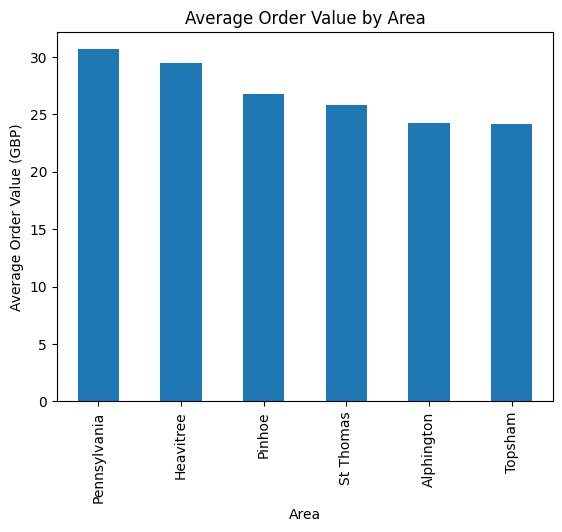

In [25]:
df.groupby("Area")["Order_Value_GBP"].mean().sort_values(ascending=False).plot(kind="bar")
plt.title("Average Order Value by Area")
plt.xlabel("Area")
plt.ylabel("Average Order Value (GBP)")
plt.show()

In [26]:
# Customers of Pennsylvania spend more money than customers from other areas.

Management can intensify more effort on marketing in the least two areas Alphington and Topsham.
